## Using ODC.STAC to load multidimensional SOLUS Data

https://odc-stac.readthedocs.io/en/latest/

In [1]:
#import odc.stac
from odc.stac import configure_rio, load
import rioxarray as rxr
import pystac

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

configure_rio(cloud_defaults=True, aws={"aws_unsigned": True})

In [2]:
rxr.show_versions()

rioxarray (0.21.0) deps:
  rasterio: 1.5.0
    xarray: 2025.11.0
      GDAL: 3.12.2
      GEOS: 3.14.1
      PROJ: 9.7.1
 PROJ DATA: /Users/scotthenderson/GitHub/cresst/solus-stac/.pixi/envs/default/share/proj
 GDAL DATA: /Users/scotthenderson/GitHub/cresst/solus-stac/.pixi/envs/default/share/gdal

Other python deps:
     scipy: 1.17.0
    pyproj: 3.7.2

System:
    python: 3.13.12 | packaged by conda-forge | (main, Feb  5 2026, 06:11:05) [Clang 19.1.7 ]
executable: /Users/scotthenderson/GitHub/cresst/solus-stac/.pixi/envs/default/bin/python
   machine: macOS-26.3.1-arm64-arm-64bit-Mach-O


In [3]:
# Load a single Item  (basically STAC acts as a VRT)
# Rasterio/GDAL 3.12 automatically loads all stac assets in a dataset!
# Annoyingly the names appear as `asset=cec7` instead of just `cec7`
# Also, the 'scale' in attributes is incorrect... not sure if this is a GDAL/rasterio/xarray issue
local_item = './stac/p/depth_0cm/depth_0cm.json'
ds = rxr.open_rasterio(local_item)

In [4]:
# overviews don't work though..
#ds = rxr.open_rasterio(local_item, overview_level=2)
#ds

In [5]:
# Open single asset only, now overviews work (b/c single asset=COG)
da = rxr.open_rasterio(f'STACIT:{local_item}:asset=cec7', overview_level=2).squeeze()
da

<xarray.DataArray (y: 3923, x: 6226)> Size: 49MB
[24424598 values with dtype=uint16]
Coordinates:
  * y            (y) float64 31kB 3.258e+06 3.257e+06 ... 1.202e+05 1.194e+05
  * x            (x) float64 50kB -2.54e+06 -2.539e+06 ... 2.44e+06 2.441e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    65535
    scale_factor:  1.0
    add_offset:    0.0

In [6]:
# Construct a multdimensional xarray with odc.stac

item = pystac.Item.from_file(local_item)
#ds = load([item]) # GOTCHA reads entire file into memory unless chunks set
ds = load([item],
          chunks={'x': 512, 'y': 512},
          bands=['cec7'],
)
ds

<xarray.Dataset> Size: 2GB
Dimensions:      (y: 31390, x: 49810, time: 1)
Coordinates:
  * y            (y) float64 251kB 3.258e+06 3.258e+06 ... 1.192e+05 1.19e+05
  * x            (x) float64 398kB -2.54e+06 -2.54e+06 ... 2.441e+06 2.441e+06
  * time         (time) datetime64[us] 8B 2023-12-15
    spatial_ref  int32 4B 5070
Data variables:
    cec7         (time, y, x) uint8 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

Note that odcstac has some additional smarts icluding setting the time coordinate instead of default band=1. also we see the EPSG code 5070 in spatial_ref coord.

In [7]:
# ALso, the returned dataset still works with rioxarray.
ds.rio.crs

CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]')

In [8]:
# Now let's use 'depth' instad of time as the 3rd dimension
# Interestigly this does a bunch of stuff, but doesn't really construct a logical nD dataset
# item_collection = pystac.ItemCollection.from_file('./stac/item_collection.json')
# ds = load(item_collection,
#           chunks={'x': 512, 'y': 512}
# )

In [9]:
ds = load([item],
          bands=['caco3','cec7'],
          chunks={'x': 512, 'y': 512}
)
ds

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 31390, x: 49810, time: 1)
Coordinates:
  * y            (y) float64 251kB 3.258e+06 3.258e+06 ... 1.192e+05 1.19e+05
  * x            (x) float64 398kB -2.54e+06 -2.54e+06 ... 2.441e+06 2.441e+06
  * time         (time) datetime64[us] 8B 2023-12-15
    spatial_ref  int32 4B 5070
Data variables:
    caco3        (time, y, x) uint8 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    cec7         (time, y, x) uint8 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

In [10]:
# Loading multiple variables by
collection = pystac.read_file('./stac/p/collection.json')
items = collection.get_all_items()
ds = load(items,
          #groupby='junk', # huh, rather than errors seems to fallback to 'time'
          groupby='depth',
          #bands=['caco3'],
          chunks={'x': 512, 'y': 512},
          resolution=800, # should pick up overviews (100,200,400,etc...)
          #with_properties=['depth'] # NOTE: shows up as a data variable rather than coordinate a la stackstac!
)
ds

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 3925, x: 6227, time: 7)
Coordinates:
  * y            (y) float64 31kB 3.258e+06 3.257e+06 ... 1.196e+05 1.188e+05
  * x            (x) float64 50kB -2.54e+06 -2.539e+06 ... 2.44e+06 2.441e+06
  * time         (time) datetime64[us] 56B 2023-12-15 2023-12-15 ... 2023-12-15
    spatial_ref  int32 4B 5070
Data variables: (12/18)
    caco3        (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    cec7         (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    claytotal    (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    dbovendry    (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ec           (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ecec         (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ...           ...
    sandtotal    (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    sandvc       (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    sandvf       (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    sar          (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    silttotal    (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    soc          (time, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

In [11]:
# NOTE: that odc.stac always returns time, so we need some logic to reconstruct the complete nD dataset
# with the correct coordinates

# Can extract more coordinates, etc
collection = pystac.read_file('./stac/p/collection.json')
items = collection.get_all_items()
all_items = list(items)

ds = ds.rename({'time':'depth'})
ds['depth'] = [x.properties['depth'] for x in all_items]
ds

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 3925, x: 6227, depth: 7)
Coordinates:
  * y            (y) float64 31kB 3.258e+06 3.257e+06 ... 1.196e+05 1.188e+05
  * x            (x) float64 50kB -2.54e+06 -2.539e+06 ... 2.44e+06 2.441e+06
  * depth        (depth) int64 56B 0 5 15 30 60 100 150
    spatial_ref  int32 4B 5070
Data variables: (12/18)
    caco3        (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    cec7         (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    claytotal    (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    dbovendry    (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ec           (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ecec         (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ...           ...
    sandtotal    (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    sandvc       (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    sandvf       (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    sar          (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    silttotal    (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    soc          (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

In [12]:
ds['caco3'].rio.nodata

np.uint8(255)

/Users/scotthenderson/GitHub/cresst/solus-stac/.pixi/envs/default/lib/python3.13/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


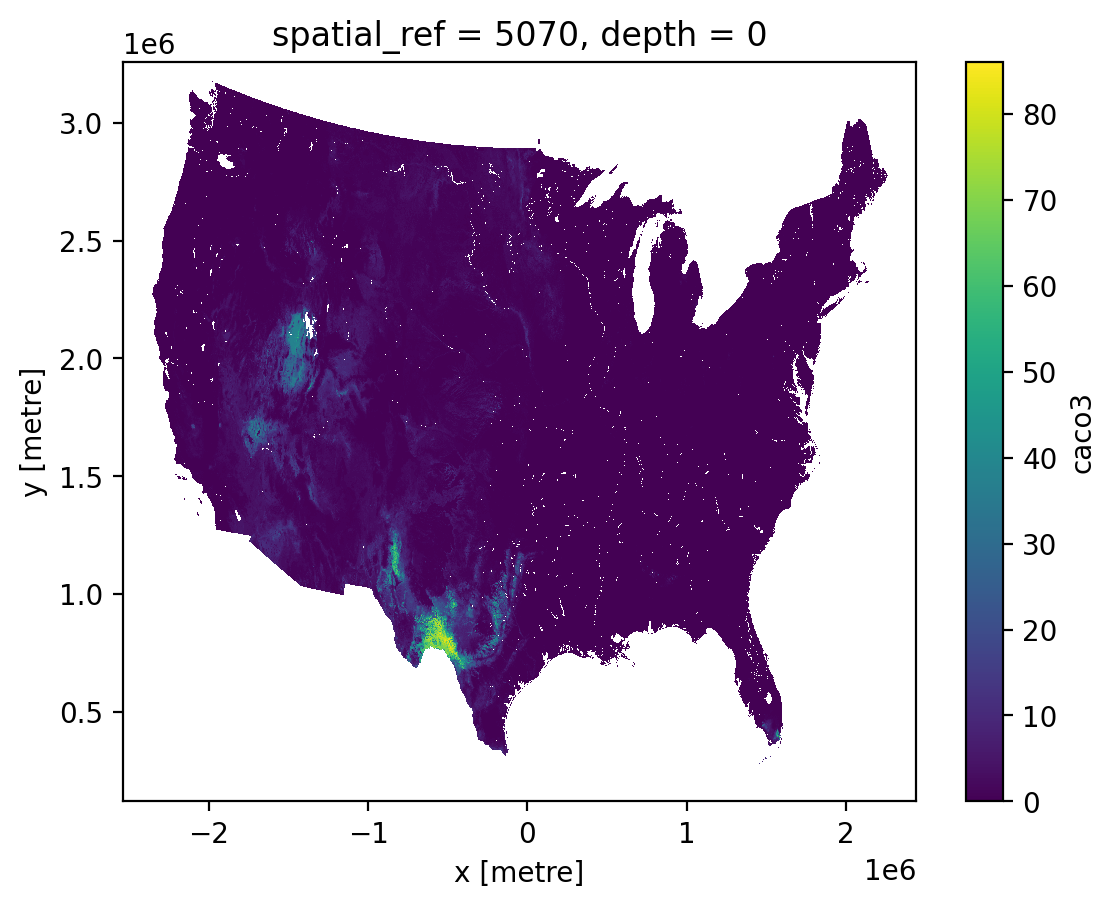

In [13]:
# Santity check

# NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
da_c = ds['caco3'].sel(depth=0)
da_c.where(da_c != da_c.rio.nodata).plot.imshow()

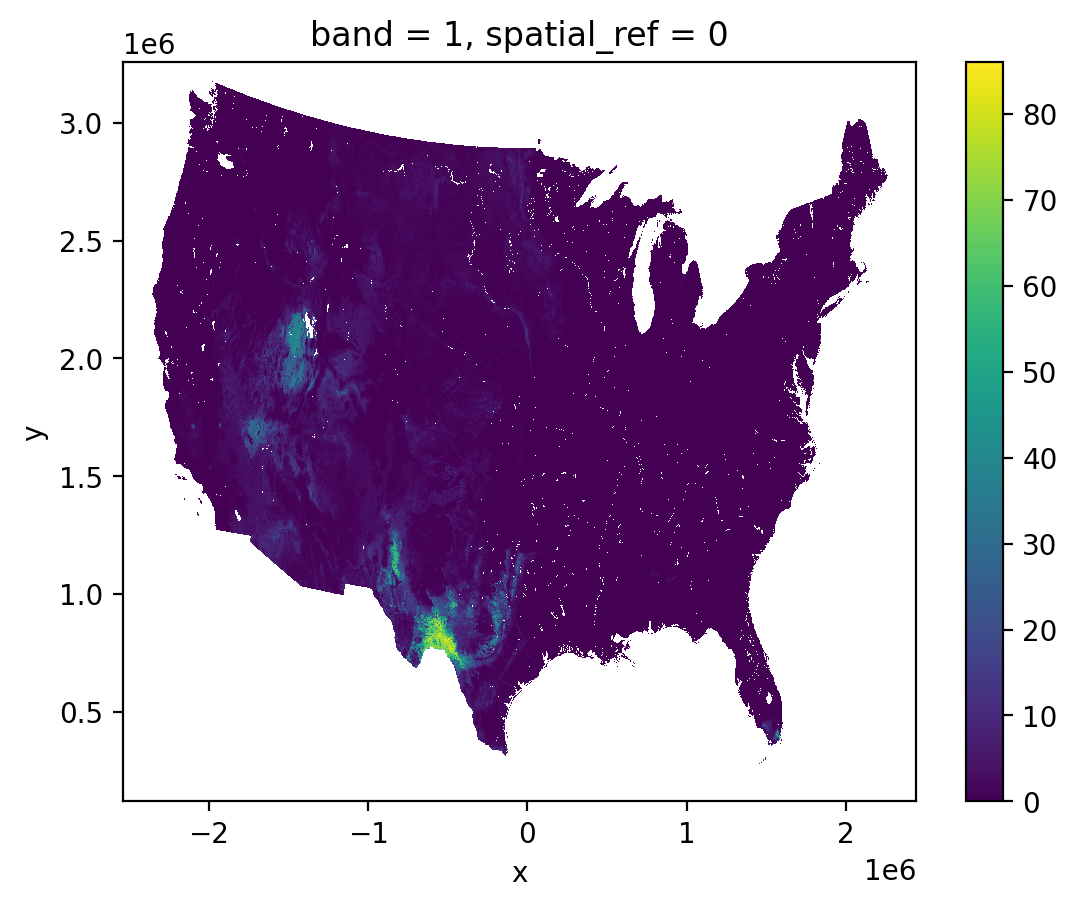

In [14]:
# Open single asset only, now overviews work (b/c single asset=COG)
# NOTE: not quite the same as overview, but close
da = rxr.open_rasterio(f'STACIT:{local_item}:asset=caco3', overview_level=2).squeeze()
da.where(da != da.rio.nodata).plot.imshow()

In [15]:
# Soil properties
item = pystac.read_file('./stac/soil_thickness/p/p.json')
ds_thickness = load([item],
                    chunks={'x': 512, 'y': 512},
                    resolution=800, # should pick up overviews (100,200,400,etc...)
)
ds_thickness

<xarray.Dataset> Size: 49MB
Dimensions:       (y: 3925, x: 6227, time: 1)
Coordinates:
  * y             (y) float64 31kB 3.258e+06 3.257e+06 ... 1.196e+05 1.188e+05
  * x             (x) float64 50kB -2.54e+06 -2.539e+06 ... 2.44e+06 2.441e+06
  * time          (time) datetime64[us] 8B 2023-12-15
    spatial_ref   int32 4B 5070
Data variables:
    anylithicdpt  (time, y, x) uint8 24MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    resdept       (time, y, x) uint8 24MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

## Fully merged dataset 

In [16]:
import xarray as xr
DS = xr.merge([ds, ds_thickness])

## Annotate DataArrays with STAC asset metadata

Unfortunately ODC.STAC does not currently automatically apply GeoTIFF scale and offset on read. This is 1. because the Geotiffs do not embed the data directly and 2. by default the rasterio reader also does not do this automatically, it's up to the user to apply the scale and offset.

Another workaround would be to use GDAL vrt:// strings to get *GDAL* to apply the scale on read:
`GDAL_DISABLE_READDIR_ON_OPEN=EMPTY_DIR gdal raster info "vrt:///vsicurl/https://storage.googleapis.com/solus100pub/cec7_100_cm_p.tif?a_scale=0.01&scale=True&ovr=4" --stats`

Or do postprocessing with the following function that reads `raster:bands` entries from a STAC Item JSON and applies `scale` and `unit` as `attrs` on each matching `DataArray` in an `xarray.Dataset`.

In [17]:
import json
import xarray as xr


def annotate_from_stac(ds: xr.Dataset, stac_path: str) -> xr.Dataset:
    """Annotate DataArrays in *ds* with metadata from a STAC Item JSON.

    For each asset in the Item whose key matches a variable in *ds*, the
    following fields are copied into the DataArray's ``attrs``:

    - ``description``: asset ``title``
    - ``scale``: from ``raster:bands[0].scale`` (when present)
    - ``unit``: from ``raster:bands[0].unit`` (when present)

    Parameters
    ----------
    ds : xr.Dataset
        Dataset whose variable names correspond to STAC asset keys.
    stac_path : str
        Path (or URL) to a STAC Item JSON file.

    Returns
    -------
    xr.Dataset
        The same dataset with updated ``attrs`` on matching variables.
    """
    with open(stac_path) as f:
        item = json.load(f)

    for asset_key, asset in item.get("assets", {}).items():
        if asset_key not in ds:
            continue
        extra = {}
        if "title" in asset:
            extra["description"] = asset["title"]
        bands = asset.get("raster:bands", [])
        if bands:
            band = bands[0]
            if "scale" in band:
                extra["scale"] = band["scale"]
            if "unit" in band:
                extra["unit"] = band["unit"]
        if extra:
            ds[asset_key].attrs.update(extra)

    return ds


# Example: annotate the prediction dataset loaded from the p collection
ds = annotate_from_stac(DS, './stac/p/depth_0cm/depth_0cm.json')
ds['cec7'].attrs

{'nodata': 255,
 'description': 'Cation Exchange Capacity (pH 7) (meq/100g)',
 'scale': 0.1,
 'unit': 'meq/100g'}

In [18]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:       (y: 3925, x: 6227, depth: 7, time: 1)
Coordinates:
  * y             (y) float64 31kB 3.258e+06 3.257e+06 ... 1.196e+05 1.188e+05
  * x             (x) float64 50kB -2.54e+06 -2.539e+06 ... 2.44e+06 2.441e+06
  * depth         (depth) int64 56B 0 5 15 30 60 100 150
  * time          (time) datetime64[us] 8B 2023-12-15
    spatial_ref   int32 4B 5070
Data variables: (12/20)
    caco3         (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    cec7          (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    claytotal     (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    dbovendry     (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ec            (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ecec          (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ...            ...
    sandvf        (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    sar           (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    silttotal     (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    soc           (depth, y, x) uint8 171MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    anylithicdpt  (time, y, x) uint8 24MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    resdept       (time, y, x) uint8 24MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

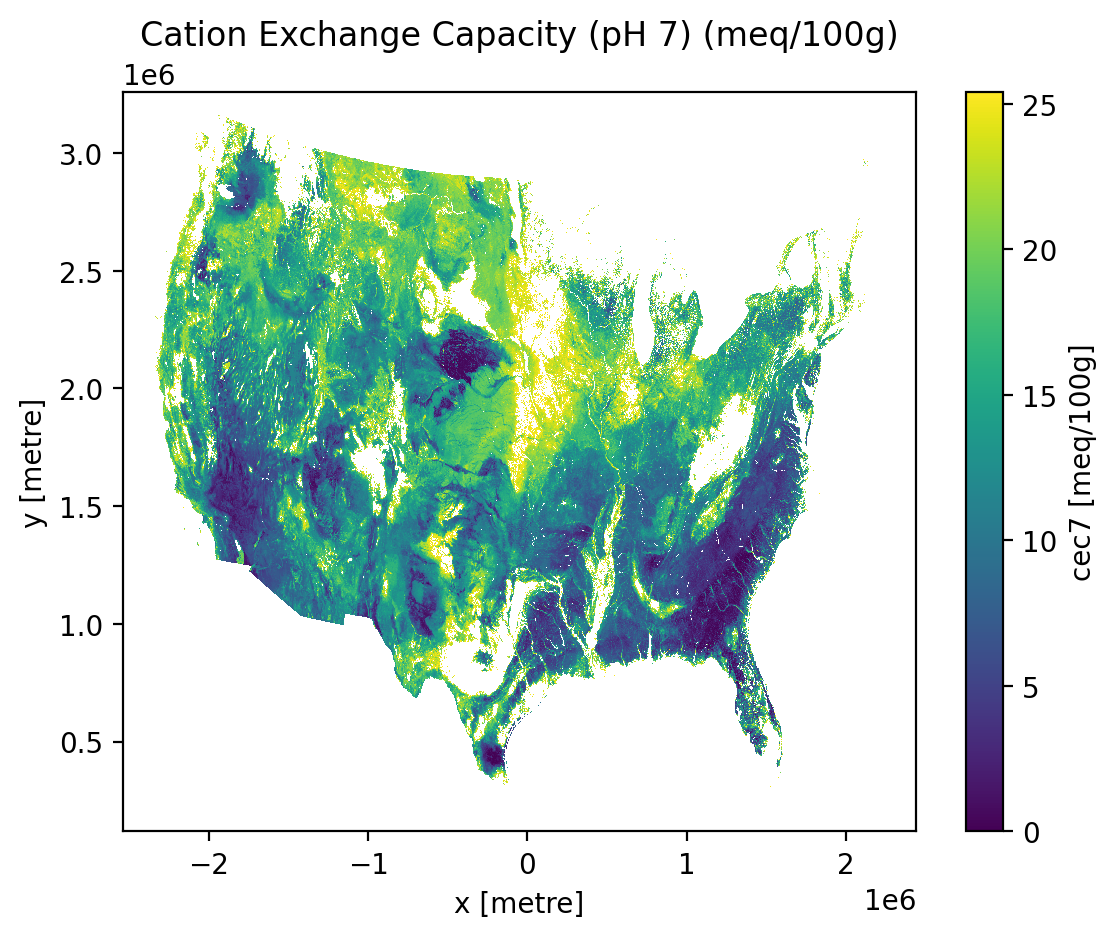

In [19]:
da = ds['cec7'].isel(depth=0)
da_scaled = (da.where(da != da.rio.nodata) * da.attrs['scale']).compute()
da_scaled.plot.imshow()
plt.title(da_scaled.attrs['description']);
